In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


os.chdir("../..")
savedir = "data/Maxwell"

In [ ]:
from src.Maxwell.plots import *
import scipy.sparse as sp
from tensorly.tucker_tensor import TuckerTensor
from src.Maxwell.error_sweeps import *
from src.Maxwell.ROM import *
from src.Maxwell.FOM import *
from src.Utils.utils import *
from src.Bases.rbf import RBFWeights
from src.Bases.lidw import lidw

In [5]:
filename = 'src/Maxwell/maxwell_data.hdf5'
file_hdf5 = h5py.File(filename, 'r')
sim = MaxwellSim(file_hdf5)
M_E = read_hdf5_sparse(file_hdf5['Emass'])

In [6]:
with np.load(os.path.join(savedir, "maxwell_B_test.npz")) as z:
    snapshots_B_test = z["B"]
    params_test = z["params"]
    times = z["t"]

with np.load(os.path.join(savedir, "maxwell_E_test.npz")) as z:
    snapshots_E_test = z["E"]
    params_test = z["params"]

snapshots_E_test.shape, snapshots_B_test.shape, params_test.shape

((49320, 121, 40), (82350, 121, 40), (40, 3))

In [ ]:
# idx = 0
# requested = [2.5]  # must be in timesteps (within tolerance)
# save_pngs(
#     sim.mesh, file_hdf5, os.path.join(savedir, "sim"),
#     recorded_times=times,
#     requested_times=requested,
#     E_arr=snapshots_E_test[...,idx],
#     B_arr=snapshots_B_test[...,idx],
#     image_size=(1250, 350),
# )

/var/folders/30/0jwhyzsj0rnb88s_49hf9shm0000gq/T/ipykernel_69967/816938555.py:70: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.16)


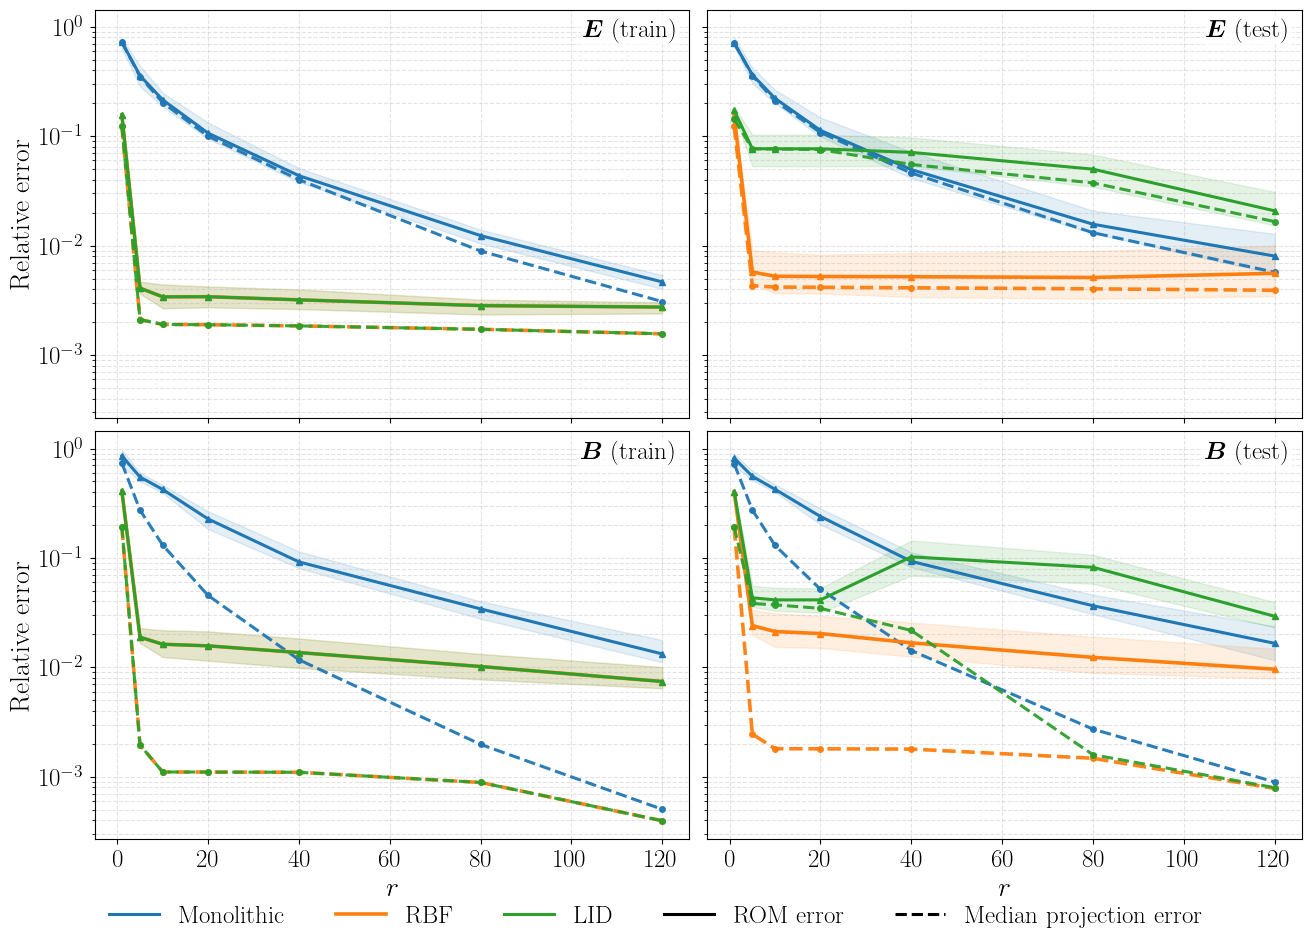

In [ ]:
plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{bm}",
    "font.size": 18,
    "font.family": "serif",
    "axes.titlesize": 18,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
})

errs = np.load(os.path.join(savedir,"errors_B_M_ortho_enriched_hyper.npz"), allow_pickle=True)
r_arr = errs["r_arr"]

methods = ["mono", "rbf", "lid"]
colors = {"mono": "C0", "rbf": "C1", "lid": "C2"}
method_labels = {"mono": r"Monolithic", "rbf": r"RBF", "lid": r"LID"}

base_lw = 2.2
lw_method = {"mono": base_lw, "rbf": base_lw + 0.4, "lid": base_lw}

def plot_subplot(ax, title_text, key_fmt_rom, key_fmt_proj):
    for m in methods:
        # ROM: median + IQR band
        A = errs[key_fmt_rom.format(m=m)]
        med = np.median(A, axis=1)
        lo  = np.quantile(A, 0.25, axis=1)
        hi  = np.quantile(A, 0.75, axis=1)
        ax.plot(r_arr, med, color=colors[m], lw=lw_method[m], marker="^", ms=5)
        ax.fill_between(r_arr, lo, hi, color=colors[m], alpha=0.12)

        # Projection: median only (dashed)
        P = errs[key_fmt_proj.format(m=m)]
        pmed = np.median(P, axis=1)
        ax.plot(r_arr, pmed, color=colors[m], lw=lw_method[m], ls="--", marker="o", ms=4, alpha=0.95)

    ax.set_yscale("log")
    ax.grid(True, which="both", ls="--", alpha=0.35)

    # Title inside (top-right corner)
    ax.text(
        0.98, 0.98, title_text,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=18,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=2.0),
    )

fig, ax = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True, sharex=True, sharey=True)

plot_subplot(ax[0,0], r"$\boldsymbol{E}$ (train)", "{m}_romE_train", "{m}_projE_train")
plot_subplot(ax[0,1], r"$\boldsymbol{E}$ (test)",  "{m}_romE_test",  "{m}_projE_test")
plot_subplot(ax[1,0], r"$\boldsymbol{B}$ (train)", "{m}_romB_train", "{m}_projB_train")
plot_subplot(ax[1,1], r"$\boldsymbol{B}$ (test)",  "{m}_romB_test",  "{m}_projB_test")

for a in ax[1,:]:
    a.set_xlabel(r"$r$")
for a in ax[:,0]:
    a.set_ylabel(r"Relative error")

method_handles = [
    Line2D([0],[0], color=colors[m], lw=lw_method[m], label=method_labels[m]) for m in methods
]
style_handles = [
    Line2D([0],[0], color="k", lw=2.2, ls="-",  label=r"ROM error"),
    Line2D([0],[0], color="k", lw=2.2, ls="--", label=r"Median projection error"),
]

fig.subplots_adjust(bottom=0.16)
fig.legend(method_handles + style_handles,
           [h.get_label() for h in (method_handles + style_handles)],
           loc="lower center", ncol=5, frameon=False, bbox_to_anchor=(0.5, -0.05))

plt.show()
